# Fase 4 - Transformer destilado en CPU

Este notebook deja listo el flujo CPU-only para el transformer. Si no hay pesos locales del modelo, la precondicion queda explicita y el resto del entrenamiento no se ejecuta.

In [10]:
from pathlib import Path
import sys

RAIZ_PROYECTO = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

from src.corpus_inmuebles import preparar_corpus_para_modelado
from src.evaluacion_modelos import (
    construir_matriz_confusion_tabla,
    construir_reporte_clasificacion,
    construir_tabla_metricas,
    dibujar_matriz_confusion_profesional,
)
from src.infraestructura_cpu import configurar_torch_cpu, relevar_hardware, sugerir_tamanio_muestra
from src.transformer_cpu import (
    NOMBRE_MODELO_TRANSFORMER,
    cargar_modelo_transformer_para_clasificacion,
    cargar_tokenizador_transformer,
    construir_mapeo_etiquetas,
    crear_dataloaders_transformer,
    cuantizar_modelo_dinamicamente,
    entrenar_transformer_en_cpu,
    predecir_con_transformer,
    relevar_estado_modelo_local,
)

In [4]:
# ============================================================================
# PASO PREVIO (Una sola vez): Descargar pesos del modelo si no existen localmente
# ============================================================================
# Esta celda descarga e cachea los pesos. Toma unos minutos pero solo es necesaria una vez.

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Verificando y descargando pesos del modelo si es necesario...")
try:
    # Descargar tokenizador
    tokenizador_hf = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
    print("✓ Tokenizador descargado y cacheado")

    # Descargar modelo base
    modelo_base = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-multilingual-cased",
        num_labels=3
    )
    print("✓ Modelo descargado y cacheado")
    print("\nLos pesos están ahora disponibles localmente. Ejecuta las siguientes celdas.")
except Exception as e:
    print(f"Error al descargar: {e}")
    print("Asegúrate de tener conexión a internet para esta descarga.")

Verificando y descargando pesos del modelo si es necesario...
✓ Tokenizador descargado y cacheado


I0000 00:00:1777056205.695672  353993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777056205.715242  353993 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777056206.270324  353993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at 

✓ Modelo descargado y cacheado

Los pesos están ahora disponibles localmente. Ejecuta las siguientes celdas.


In [11]:
print("Verificando disponibilidad de pesos del modelo DistilBERT...")
estado_modelo = relevar_estado_modelo_local(NOMBRE_MODELO_TRANSFORMER)
print()
display(estado_modelo)
print()

if not estado_modelo.loc[0, 'pesos_modelo_disponibles']:
    print("⚠️  IMPORTANTE: Los pesos del modelo NO están disponibles localmente.")
    print("Solución: Ejecuta la celda anterior ('Descargar pesos del modelo') para descargarlos.")
    print("   - Primera ejecución: ~2-3 min (descarga ~300 MB)")
    print("   - Siguientes ejecuciones: instantáneo (usa caché local)")
else:
    print("✓ Los pesos del modelo están disponibles localmente. Listo para entrenar.")

Verificando disponibilidad de pesos del modelo DistilBERT...



,nombre_modelo,tokenizador_disponible,pesos_modelo_disponibles,origen_tokenizador,origen_modelo
0,distilbert-base-multilingual-cased,True,True,/home/juan/.cache/huggingface/hub/models--dist...,/home/juan/.cache/huggingface/hub/models--dist...



✓ Los pesos del modelo están disponibles localmente. Listo para entrenar.


In [6]:
hay_pesos_locales = bool(estado_modelo.loc[0, 'pesos_modelo_disponibles'])
print(f'Pesos locales disponibles: {hay_pesos_locales}')


Pesos locales disponibles: True


## Nota metodologica sobre el `LOAD REPORT`

El mensaje `DistilBertForSequenceClassification LOAD REPORT` es esperable en este flujo y no representa un error de carga.

- `UNEXPECTED` indica que el checkpoint base trae pesos asociados a la tarea de preentrenamiento del modelo y que no son usados por la cabeza de clasificacion.
- `MISSING` indica que la cabeza de clasificacion (`pre_classifier` y `classifier`) no existe en el checkpoint base y se inicializa desde cero para la tarea supervisada de tres clases.

Metodologicamente, este comportamiento es el esperado cuando se hace fine-tuning sobre un checkpoint base de DistilBERT para `sequence classification`. Por eso el entrenamiento posterior es necesario: el encoder reutiliza pesos preentrenados, mientras que la cabeza de clasificacion aprende especificamente el problema `Departamento` vs `Casa` vs `PH`.

En este trabajo el setup se mantuvo deliberadamente acotado para asegurar ejecucion local en CPU: `batch_size=4`, `epochs=1`, `max_length=128`, cuantizacion dinamica para inferencia y sin busqueda exhaustiva de hiperparametros.


In [12]:
import torch
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer

def obtener_o_entrenar_distilbert(
    nombre_modelo_ram, 
    nombre_tokenizador_ram,
    carpeta_destino, 
    dataloader, 
    epochs, 
    learning_rate=5e-5,
    etiqueta_a_id=None,
    id_a_etiqueta=None
):
    # Cambiamos la ruta para que guarde en la carpeta artifacts en la raíz del proyecto
    carpeta = RAIZ_PROYECTO / "artifacts" / carpeta_destino
    
    # Capa 1: RAM
    if nombre_modelo_ram in globals() and isinstance(globals()[nombre_modelo_ram], torch.nn.Module) and nombre_tokenizador_ram in globals():
        print(f"✅ Cargando {nombre_modelo_ram} desde la memoria RAM...")
        return globals()[nombre_modelo_ram], globals()[nombre_tokenizador_ram]
    
    # Capa 2: Disco
    if carpeta.exists():
        print(f"✅ Cargando {nombre_modelo_ram} desde el disco ({carpeta})...")
        modelo = AutoModelForSequenceClassification.from_pretrained(carpeta)
        tokenizador = AutoTokenizer.from_pretrained(carpeta)
        return modelo, tokenizador
    
    # Capa 3: Entrenamiento
    print(f"⏳ No se encontró {nombre_modelo_ram} localmente. Iniciando entrenamiento...")
    modelo = cargar_modelo_transformer_para_clasificacion(
        cantidad_etiquetas=len(etiqueta_a_id),
        etiqueta_a_id=etiqueta_a_id,
        id_a_etiqueta=id_a_etiqueta,
    )
    tokenizador = cargar_tokenizador_transformer()
    
    historial = entrenar_transformer_en_cpu(
        modelo=modelo, 
        dataloader_entrenamiento=dataloader, 
        epochs=epochs, 
        learning_rate=learning_rate
    )
    display(historial)
    
    print(f"💾 Guardando modelo y tokenizador en {carpeta}...")
    carpeta.mkdir(parents=True, exist_ok=True)
    modelo.save_pretrained(carpeta)
    tokenizador.save_pretrained(carpeta)
    
    return modelo, tokenizador


✅ Cargando modelo desde la memoria RAM...
=== Evaluación del Modelo Transformer (DistilBERT) ===
              precision    recall  f1-score   support

        Casa     0.8466    0.8762    0.8611       913
Departamento     0.9508    0.9234    0.9369      1905
          PH     0.5902    0.6648    0.6253       182

    accuracy                         0.8933      3000
   macro avg     0.7959    0.8215    0.8078      3000
weighted avg     0.8972    0.8933    0.8949      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.8933,0.7959,0.8215,0.8078,0.8972,0.8933,0.8949


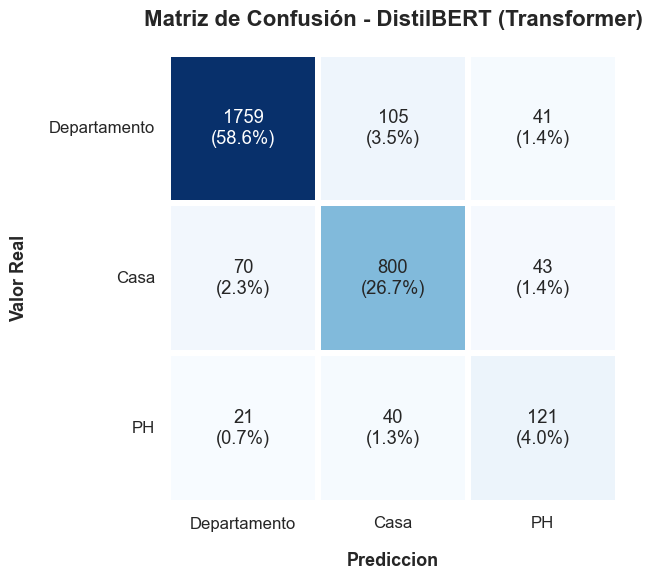

In [13]:
if hay_pesos_locales:
    RUTA_DATOS = RAIZ_PROYECTO / 'data' / 'entrenamiento.csv'
    resumen = relevar_hardware()
    configurar_torch_cpu()
    tamanio_muestra = sugerir_tamanio_muestra(resumen.memoria_disponible_gb)

    df_muestra, df_entrenamiento, df_prueba = preparar_corpus_para_modelado(
        ruta_datos=RUTA_DATOS,
        tamanio_muestra=tamanio_muestra,
        tamanio_test=0.2,
        semilla=42,
    )

    etiqueta_a_id, id_a_etiqueta = construir_mapeo_etiquetas(df_muestra['property_type'])
    tokenizador = cargar_tokenizador_transformer()

    dl_train, dl_test = crear_dataloaders_transformer(
        df_entrenamiento,
        df_prueba,
        tokenizador,
        etiqueta_a_id=etiqueta_a_id,
        batch_size=4,
        longitud_maxima=128,
    )

    modelo_temp, tokenizador_temp = obtener_o_entrenar_distilbert(
        nombre_modelo_ram="modelo",
        nombre_tokenizador_ram="tokenizador",
        carpeta_destino="distilbert_normal",
        dataloader=dl_train,
        epochs=1,
        learning_rate=5e-5,
        etiqueta_a_id=etiqueta_a_id,
        id_a_etiqueta=id_a_etiqueta
    )
    globals()["modelo"] = modelo_temp
    globals()["tokenizador"] = tokenizador_temp

    modelo_cuantizado = cuantizar_modelo_dinamicamente(modelo)
    pred_ids = predecir_con_transformer(modelo_cuantizado, dl_test)
    predicciones = [id_a_etiqueta[indice] for indice in pred_ids]

    print("=== Evaluación del Modelo Transformer (DistilBERT) ===")
    print(construir_reporte_clasificacion(df_prueba['property_type'], predicciones))
    display(construir_tabla_metricas(df_prueba['property_type'], predicciones))

    dibujar_matriz_confusion_profesional(
        df_prueba['property_type'],
        predicciones,
        etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
        titulo='Matriz de Confusión - DistilBERT (Transformer)'
    )
else:
    print("⚠️  No hay pesos locales del modelo.")
    print()
    print("PASOS PARA RESOLVER:")
    print("1. Ejecuta la celda anterior: 'Descargar pesos del modelo'")
    print("2. Luego ejecuta esta celda nuevamente")
    print()
    print("Primera vez: La descarga toma ~2-3 minutos (se cachea automáticamente)")
    print("Siguientes veces: Será instantáneo")


## DistilBERT con Datos Censurados (Sin Data Leakage)
Entrenamos el transformer usando la columna sin las palabras clave.


In [15]:
from src.property_text_pipeline import COLUMNA_TEXTO_LIMPIO_TRANSFORMER_CENSURADO

# Crear dataloaders con texto censurado
dataloader_train_censurado, dataloader_prueba_censurado = crear_dataloaders_transformer(
    df_entrenamiento=df_entrenamiento,
    df_prueba=df_prueba,
    tokenizador=tokenizador,
    etiqueta_a_id=etiqueta_a_id,
    columna_texto=COLUMNA_TEXTO_LIMPIO_TRANSFORMER_CENSURADO,
)

if hay_pesos_locales: # Cambiar a True para entrenar localmente o simular
    modelo_censurado_temp, tokenizador_temp = obtener_o_entrenar_distilbert(
        nombre_modelo_ram="modelo_censurado",
        nombre_tokenizador_ram="tokenizador",
        carpeta_destino="distilbert_censurado_1ep",
        dataloader=dataloader_train_censurado,
        epochs=1,
        learning_rate=2e-5,
        etiqueta_a_id=etiqueta_a_id,
        id_a_etiqueta=id_a_etiqueta
    )
    globals()["modelo_censurado"] = modelo_censurado_temp
    globals()["tokenizador"] = tokenizador_temp

    pred_ids_censurado = predecir_con_transformer(modelo_censurado, dataloader_prueba_censurado)
    predicciones_censurado = [id_a_etiqueta[indice] for indice in pred_ids_censurado]
    print("Transformer Censurado:")
    print(construir_reporte_clasificacion(df_prueba['property_type'], predicciones_censurado))
    display(construir_tabla_metricas(df_prueba['property_type'], predicciones_censurado))


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at /home/juan/.cache/huggingface/hub/models--distilbert-base-multilingual-cased/snapshots/45c032ab32cc946ad88a166f7cb282f58c753c2e and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⏳ No se encontró modelo_censurado localmente. Iniciando entrenamiento...


,epoch,loss_promedio
0,1,0.7783


💾 Guardando modelo y tokenizador en /home/juan/Documentos/Ciencia de Datos/08 _Seminario de procesamiento de lenguaje natural/TFI/nlp_trabajo_final/artifacts/distilbert_censurado_1ep...
Transformer Censurado:
              precision    recall  f1-score   support

        Casa     0.8762    0.7831    0.8271       913
Departamento     0.9493    0.8352    0.8886      1905
          PH     0.2500    0.6978    0.3681       182

    accuracy                         0.8110      3000
   macro avg     0.6918    0.7720    0.6946      3000
weighted avg     0.8846    0.8110    0.8383      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.811,0.6918,0.772,0.6946,0.8846,0.811,0.8383


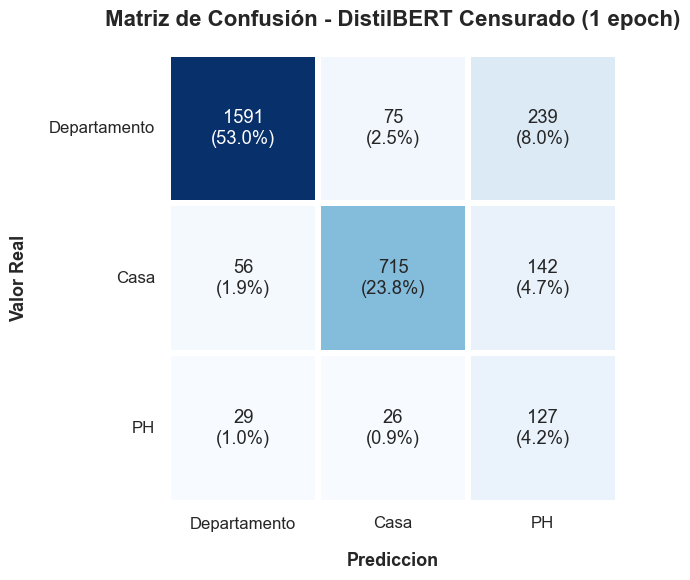

In [16]:
# Matriz de Confusión - DistilBERT Censurado (1 epoch)
if hay_pesos_locales:
    dibujar_matriz_confusion_profesional(
        df_prueba["property_type"],
        predicciones_censurado,
        etiquetas_ordenadas=["Departamento", "Casa", "PH"],
        titulo="Matriz de Confusión - DistilBERT Censurado (1 epoch)",
    )
else:
    print("⚠️ No hay pesos locales para generar la matriz de confusión censurada 1 epoch.")


In [17]:
# Reentrenamiento censurado con 2 epochs
if hay_pesos_locales:
    modelo_censurado_2ep_temp, tokenizador_temp = obtener_o_entrenar_distilbert(
        nombre_modelo_ram="modelo_censurado_2ep",
        nombre_tokenizador_ram="tokenizador",
        carpeta_destino="distilbert_censurado_2ep",
        dataloader=dataloader_train_censurado,
        epochs=2,
        learning_rate=2e-5,
        etiqueta_a_id=etiqueta_a_id,
        id_a_etiqueta=id_a_etiqueta
    )
    globals()["modelo_censurado_2ep"] = modelo_censurado_2ep_temp
    globals()["tokenizador"] = tokenizador_temp

    pred_ids_censurado_2ep = predecir_con_transformer(modelo_censurado_2ep, dataloader_prueba_censurado)
    predicciones_censurado_2ep = [id_a_etiqueta[indice] for indice in pred_ids_censurado_2ep]
    print("Transformer Censurado (2 epochs):")
    print(construir_reporte_clasificacion(df_prueba["property_type"], predicciones_censurado_2ep))
    display(construir_tabla_metricas(df_prueba["property_type"], predicciones_censurado_2ep))


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at /home/juan/.cache/huggingface/hub/models--distilbert-base-multilingual-cased/snapshots/45c032ab32cc946ad88a166f7cb282f58c753c2e and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⏳ No se encontró modelo_censurado_2ep localmente. Iniciando entrenamiento...


,epoch,loss_promedio
0,1,0.7544
1,2,0.5167


💾 Guardando modelo y tokenizador en /home/juan/Documentos/Ciencia de Datos/08 _Seminario de procesamiento de lenguaje natural/TFI/nlp_trabajo_final/artifacts/distilbert_censurado_2ep...
Transformer Censurado (2 epochs):
              precision    recall  f1-score   support

        Casa     0.8763    0.8072    0.8404       913
Departamento     0.9734    0.8252    0.8932      1905
          PH     0.2555    0.7637    0.3829       182

    accuracy                         0.8160      3000
   macro avg     0.7017    0.7987    0.7055      3000
weighted avg     0.9003    0.8160    0.8462      3000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.816,0.7017,0.7987,0.7055,0.9003,0.816,0.8462


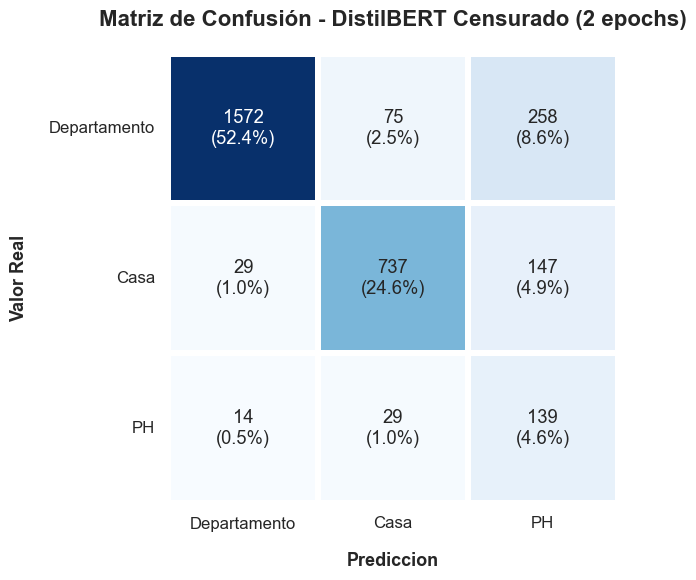

In [18]:
# Matriz de Confusión - DistilBERT Censurado (2 epochs)
if hay_pesos_locales:
    dibujar_matriz_confusion_profesional(
        df_prueba["property_type"],
        predicciones_censurado_2ep,
        etiquetas_ordenadas=["Departamento", "Casa", "PH"],
        titulo="Matriz de Confusión - DistilBERT Censurado (2 epochs)",
    )
else:
    print("⚠️ No hay pesos locales para generar la matriz de confusión censurada 2 epochs.")
